## FGI 감정 분류 - 전처리 (VSCode 서버용)

터미널에서 미리 실행하세요
```
pip install mediapipe opencv-python-headless albumentations scikit-learn tqdm numpy pandas matplotlib koreanize-matplotlib
wget https://storage.googleapis.com/mediapipe-models/face_detector/blaze_face_short_range/float16/1/blaze_face_short_range.tflite -O /workspace/user3/out/detector.tflite
```

## 1. 라이브러리 임포트

In [1]:
# Step 1: 라이브러리 임포트 및 한글 폰트 설정
# 이미지 처리(cv2), 딥러닝 전처리(mediapipe, albumentations), 데이터 처리(numpy, pandas) 임포트
import os, cv2, json, random, shutil
import numpy as np
import pandas as pd
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import albumentations as A
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.font_manager as fm
import matplotlib
from pathlib import Path
from tqdm import tqdm  # tqdm.notebook 대신 tqdm 사용 (VSCode 터미널용)
from sklearn.utils.class_weight import compute_class_weight

# koreanize_matplotlib: import만 해도 자동으로 한글 폰트 적용
import koreanize_matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

print('라이브러리 준비 완료')

/home/user3/.conda/envs/G-kwr/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


라이브러리 준비 완료


## 2. 경로 설정
BASE_PATH만 본인 서버 경로에 맞게 수정하세요.

In [2]:
# Step 2: 경로 설정
# 여기만 수정
BASE_PATH = '/workspace/shared/data'

# INPUT_DIR: EDA에서 생성한 data_split 폴더
# SEG_DIR:   원본 세그멘테이션 폴더
# OUTPUT_DIR: user3 로컬에 먼저 저장 -> 확인 후 mv로 shared에 옮기는 방식
# PLOT_DIR:  시각화 PNG 저장 폴더 (확인 후 삭제 가능)
# STAT_DIR:  통계 결과 CSV/JSON 저장 폴더 (확인 후 삭제 가능)
# MODEL_PATH: MediaPipe 모델 (터미널에서 wget으로 미리 받아두는 방식)
INPUT_DIR  = Path(BASE_PATH) / 'processed' / 'data_split'
SEG_DIR    = Path(BASE_PATH) / 'raw' / 'faceData' / 'segmentation'
OUTPUT_DIR = Path('/workspace/user3/out/data_processed_v6')
PLOT_DIR   = Path('/workspace/user3/out/plots_v6')
STAT_DIR   = Path('/workspace/user3/out/stats_v6')
MODEL_PATH = Path('/workspace/user3/out/detector.tflite')

CLASSES        = ['anger', 'happy', 'panic', 'sadness']
SPLITS         = ['train', 'val', 'test']
IMG_EXT        = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}  # 허용 이미지 확장자
TARGET_SIZE    = (224, 224)   # 모델 입력 크기
MARGIN         = 0.2          # 얼굴 크롭 시 주변 맥락 포함 비율 (20%)
FACE_RATIO_MIN = 2.9          # 얼굴 비율 최소 기준 (%), 미만이면 블랙리스트 처리 (기존 5.0 → 2.9으로 완화)

# 출력 폴더가 없으면 자동 생성
# parents=True: 중간 경로도 함께 생성, exist_ok=True: 이미 있어도 오류 없음
PLOT_DIR.mkdir(parents=True, exist_ok=True)
STAT_DIR.mkdir(parents=True, exist_ok=True)

# 경로 존재 여부 확인
# 하나라도 없으면 이후 셀이 전부 실패하므로 여기서 미리 차단
all_ok = True
for name, path in [('INPUT_DIR', INPUT_DIR), ('SEG_DIR', SEG_DIR), ('MODEL_PATH', MODEL_PATH)]:
    status = 'OK' if path.exists() else 'NOT FOUND'
    if status == 'NOT FOUND':
        all_ok = False
    print(f'[{status}] {name}: {path}')

if not all_ok:
    # 조용히 넘어가면 이후 셀에서 원인 파악이 어려워짐 -> 즉시 중단
    raise FileNotFoundError('위 경로를 확인하세요. 터미널에서 wget으로 모델을 받았는지도 확인하세요.')

[OK] INPUT_DIR: /workspace/shared/data/processed/data_split
[OK] SEG_DIR: /workspace/shared/data/raw/faceData/segmentation
[OK] MODEL_PATH: /workspace/user3/out/detector.tflite


## 3. Face Ratio 블랙리스트 생성
face_ratio 2.9% 미만 이미지를 전처리 대상에서 제외합니다.

In [3]:
# Step 3: 블랙리스트 생성
# segmentation NPZ에서 face_ratio를 계산해 기준 미만 파일명을 수집
# train/val만 검사 (test는 segmentation 없을 수 있음)

# 이미 생성된 블랙리스트가 있으면 로드하고 건너뜀
if (STAT_DIR / 'blacklist.csv').exists():
    df_black  = pd.read_csv(STAT_DIR / 'blacklist.csv', encoding='utf-8-sig')
    blacklist = set(df_black['filename'].tolist())
    print(f'[로드] 기존 블랙리스트 사용: {len(blacklist)}장')

else:
    blacklist        = set()   # 빠른 조회를 위해 set 사용 (리스트보다 in 연산이 빠름)
    blacklist_detail = []      # 클래스별 현황 파악용

    tasks = []
    for split in ['train', 'val']:
        for cls in CLASSES:
            seg_folder = SEG_DIR / split
            seg_files  = list(seg_folder.glob(f'*{cls}*.npz'))

            if not seg_files:
                raise FileNotFoundError(
                    f'[ERROR] {split}/{cls}: NPZ 파일 없음. SEG_DIR 경로를 확인하세요.')

            for sf in seg_files:
                tasks.append((split, cls, sf))

    for split, cls, sf in tqdm(tasks, desc='블랙리스트 생성'):
        data = np.load(str(sf), allow_pickle=True)
        for filename, mask in data.items():
            total_px       = mask.size or 1
            unique, counts = np.unique(mask, return_counts=True)
            px             = dict(zip(unique.tolist(), counts.tolist()))
            face_ratio     = px.get(4, 0) / total_px * 100

            if face_ratio < FACE_RATIO_MIN:
                fname = Path(filename).name
                blacklist.add(fname)
                blacklist_detail.append({
                    'split': split, 'class': cls,
                    'filename': fname, 'face_ratio': round(face_ratio, 2)
                })

    df_black = pd.DataFrame(blacklist_detail)
    print(f'블랙리스트 총 {len(blacklist)}장 (face_ratio < {FACE_RATIO_MIN}%)')
    if not df_black.empty:
        print('\n=== 클래스별 제외 수량 ===')
        print(df_black.groupby(['split', 'class']).size().rename('제외 수'))

    df_black.to_csv(STAT_DIR / 'blacklist.csv', index=False, encoding='utf-8-sig')
    print(f'[저장] {STAT_DIR}/blacklist.csv')

[로드] 기존 블랙리스트 사용: 225장


## 4. MediaPipe 얼굴 감지 & 크롭 함수 정의

In [4]:
# Step 4: MediaPipe 얼굴 감지기 초기화 (최신 Tasks API)
# 구버전 mp.solutions 방식에서 mediapipe.tasks 방식으로 변경
# blaze_face_short_range: 근거리 얼굴 감지에 최적화, 속도와 정확도 균형이 좋음

# OpenGL라이브러리가 없는 관계로... apt-get install -y libgles2 <- 안먹힘 관리자 전용 아래방식 채용이 안되네... OpenCV로 가야하는데 그러면 문제가 더 생겨서 작업 중지 관리자에게 요청 보냄
# pip uninstall mediapipe -y
# pip install mediapipe==0.10.5

base_options = python.BaseOptions(model_asset_path=str(MODEL_PATH))
options      = vision.FaceDetectorOptions(
    base_options=base_options,
    min_detection_confidence=0.5  # 신뢰도 50% 미만 감지 결과 무시
)
detector = vision.FaceDetector.create_from_options(options)

def crop_face(image_bgr):
    # BGR 이미지에서 얼굴 감지 후 MARGIN 포함 크롭
    # 얼굴이 감지되지 않으면 None 반환
    # 여러 얼굴이 감지될 경우 신뢰도가 가장 높은 얼굴을 사용
    h, w     = image_bgr.shape[:2]
    img_rgb  = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)  # MediaPipe는 RGB 입력

    # 최신 API는 mp.Image 형식으로 변환 필요
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
    result   = detector.detect(mp_image)

    if not result.detections:
        return None

    # 신뢰도가 가장 높은 얼굴 선택
    detection = max(result.detections, key=lambda d: d.categories[0].score)
    bbox      = detection.bounding_box

    # MARGIN을 추가해 얼굴 주변 맥락 포함
    x1 = int(bbox.origin_x - MARGIN * bbox.width)
    y1 = int(bbox.origin_y - MARGIN * bbox.height)
    x2 = int(bbox.origin_x + bbox.width  * (1 + MARGIN))
    y2 = int(bbox.origin_y + bbox.height * (1 + MARGIN))

    # 이미지 경계를 벗어나지 않도록 클리핑
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(w, x2), min(h, y2)

    return image_bgr[y1:y2, x1:x2]

print('얼굴 감지 함수 준비 완료 (최신 Tasks API)')

I0000 00:00:1776746039.694285  397939 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5


얼굴 감지 함수 준비 완료 (최신 Tasks API)


I0000 00:00:1776746040.085894  397958 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 570.195.03), renderer: NVIDIA A40/PCIe/SSE2
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1776746040.095507  397947 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


## 5. Augmentation 정의
train 데이터에만 적용하고 val / test는 리사이즈만 합니다.

In [5]:
# Step 5: Transform 파이프라인 정의
# 증강은 모델링 DataLoader에서 온라인으로 적용하므로 전처리에서는 Resize만 수행
# 이유: 오프라인 증강(저장)은 매 에폭마다 같은 이미지를 반복 학습하는 문제가 있음
#       온라인 증강(DataLoader)은 에폭마다 다른 변형을 만들어 데이터 다양성을 극대화
train_transform = A.Compose([
    A.Resize(224, 224),   # 크롭 후 모델 입력 크기로 리사이즈만 수행
])

# val/test도 동일하게 리사이즈만 적용
val_transform = A.Compose([
    A.Resize(224, 224),
])

print('Transform 파이프라인 준비 완료')
print('  Train/Val/Test: Resize only (증강은 DataLoader에서 온라인 적용)')


Transform 파이프라인 준비 완료
  Train/Val/Test: Resize only (증강은 DataLoader에서 온라인 적용)


## 6. 전처리 실행

In [6]:
# Step 6: 기존 data_processed 폴더 초기화
# 이전 전처리 결과가 남아있으면 새 결과와 섞일 수 있으므로 먼저 삭제
if OUTPUT_DIR.exists():
    shutil.rmtree(str(OUTPUT_DIR))  # 폴더 전체 삭제
    print(f'삭제 완료: {OUTPUT_DIR}')
else:
    print(f'폴더 없음, 그대로 진행: {OUTPUT_DIR}')

폴더 없음, 그대로 진행: /workspace/user3/out/data_processed_v6


In [7]:
# Step 7: 전처리 실행
# 처리 흐름: 블랙리스트 필터링 -> 얼굴 감지 & 크롭 -> Resize -> 저장 (증강은 DataLoader에서)

# 전체 카운터: 최종 요약 출력용
success_count   = 0
skip_blacklist  = 0
skip_no_face    = 0
skip_error      = 0
no_face_samples = []  # 얼굴 미감지 샘플 시각화용 (클래스별 최대 2장)
process_log     = []  # 클래스별 상세 처리 결과 저장용

for split in SPLITS:
    # train/val/test 모두 Resize만 (증강은 모델링 DataLoader에서 온라인 적용)
    transform = train_transform if split == 'train' else val_transform

    for cls in CLASSES:
        in_dir  = INPUT_DIR  / split / cls
        out_dir = OUTPUT_DIR / split / cls

        if not in_dir.exists():
            # 폴더가 없으면 EDA data_split 경로가 잘못된 것이므로 즉시 중단
            raise FileNotFoundError(
                f'[ERROR] 입력 폴더 없음: {in_dir}. INPUT_DIR 경로를 확인하세요.')

        out_dir.mkdir(parents=True, exist_ok=True)

        image_paths = [p for p in in_dir.glob('*') if p.suffix.lower() in IMG_EXT]
        # 클래스별 카운터: process_log에 상세 기록하기 위함
        cls_success = cls_blacklist = cls_no_face = cls_error = 0

        for img_path in tqdm(image_paths, desc=f'{split}/{cls}'):
            # 1. 블랙리스트 필터링
            # set의 in 연산: O(1) 조회로 리스트보다 훨씬 빠름
            if img_path.name in blacklist:
                skip_blacklist += 1
                cls_blacklist  += 1
                continue

            # 2. 이미지 읽기
            # cv2.imread 실패 시 None 반환 (손상 파일 또는 권한 문제)
            img = cv2.imread(str(img_path))
            if img is None:
                skip_error += 1
                cls_error  += 1
                continue

            # 3. 얼굴 감지 & 크롭
            face = crop_face(img)
            if face is None:
                skip_no_face += 1
                cls_no_face  += 1
                # 미감지 샘플 최대 2장씩 수집 (시각화용)
                if len([s for s in no_face_samples if s['class'] == cls]) < 2:
                    no_face_samples.append({'class': cls, 'path': str(img_path)})
                continue

            # 4. Resize 적용 (증강은 DataLoader에서 온라인으로 처리)
            # albumentations은 RGB 입력 -> cv2 BGR을 RGB로 변환 후 적용
            face_rgb   = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
            augmented  = transform(image=face_rgb)['image']
            result_bgr = cv2.cvtColor(augmented, cv2.COLOR_RGB2BGR)  # 저장용으로 BGR 복구

            # 5. 저장
            cv2.imwrite(str(out_dir / img_path.name), result_bgr)
            success_count += 1
            cls_success   += 1

        # 클래스별 처리 결과 기록
        process_log.append({
            'split': split, 'class': cls,
            'success': cls_success, 'blacklist': cls_blacklist,
            'no_face': cls_no_face, 'error': cls_error
        })

print('=' * 50)
print(f'성공:            {success_count}장')
print(f'블랙리스트 제외:  {skip_blacklist}장')
print(f'얼굴 미감지:      {skip_no_face}장')
print(f'파일 오류:        {skip_error}장')
print('=' * 50)

# 처리 결과 로그 저장
df_log = pd.DataFrame(process_log)
df_log.to_csv(STAT_DIR / 'process_log.csv', index=False, encoding='utf-8-sig')
print(f'[저장] {STAT_DIR}/process_log.csv')

train/anger:   0%|          | 5/1260 [00:04<16:04,  1.30it/s]

test/sadness: 100%|██████████| 180/180 [01:50<00:00,  1.63it/s]

성공:            6971장
블랙리스트 제외:  225장
얼굴 미감지:      0장
파일 오류:        0장
[저장] /workspace/user3/out/stats_v6/process_log.csv


## 7. 전처리 전후 비교 시각화
원본 → 크롭 → 증강 3단계를 클래스별로 확인합니다.

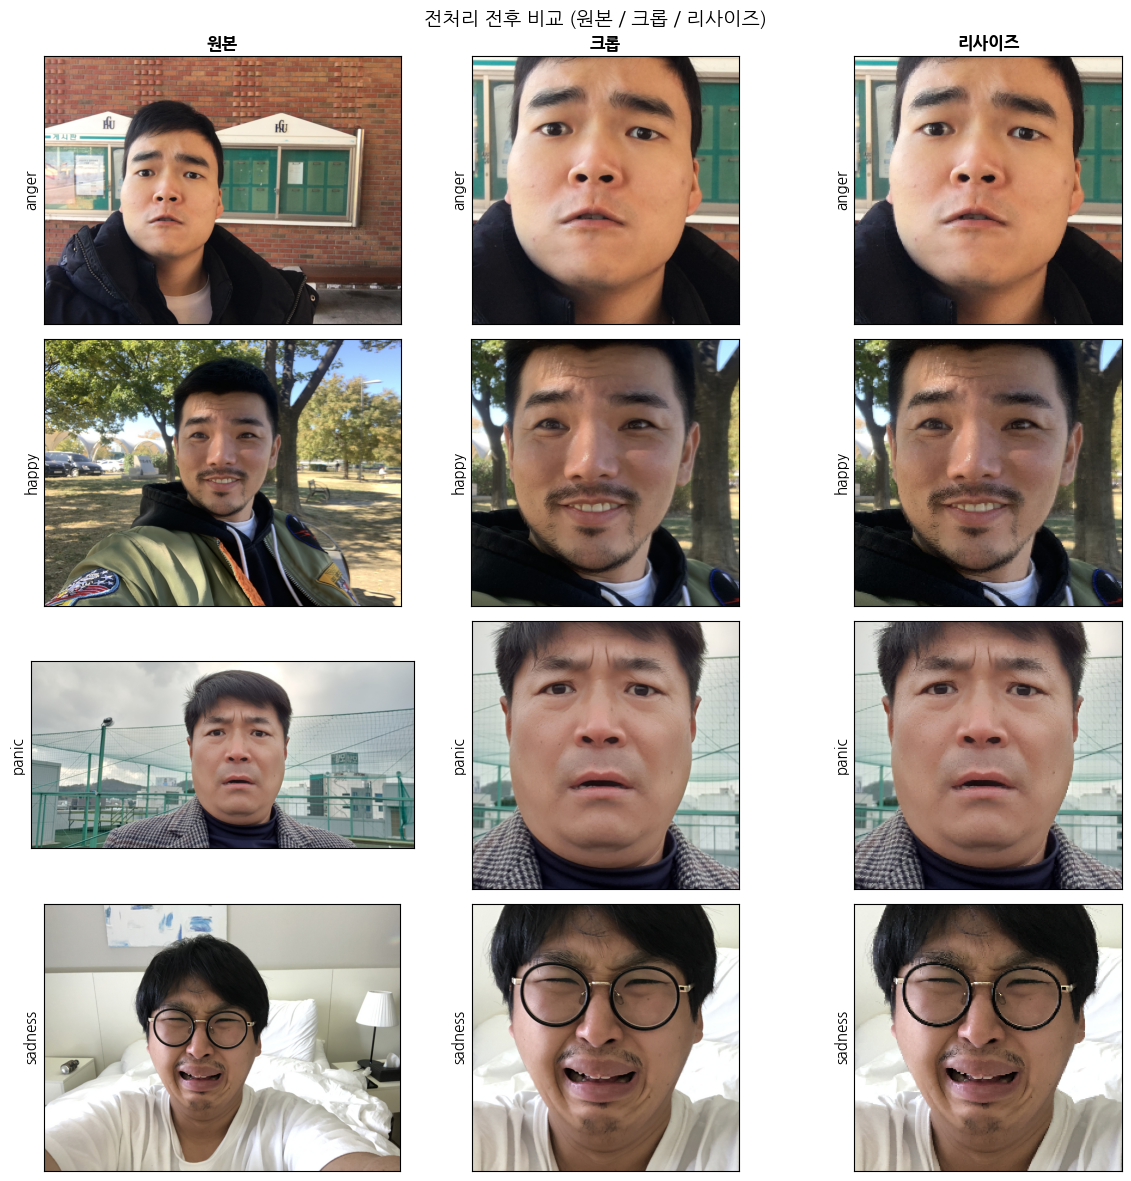

[저장] /workspace/user3/out/plots_v6/preprocess_comparison.png


In [8]:
# Step 8: 전처리 전후 비교 시각화
# 원본 / 크롭 / 증강 3단계를 나란히 보여줘서 처리가 의도대로 됐는지 확인
fig, axes = plt.subplots(len(CLASSES), 3, figsize=(12, len(CLASSES) * 3))
fig.suptitle('전처리 전후 비교 (원본 / 크롭 / 리사이즈)', fontsize=14)

col_titles = ['원본', '크롭', '리사이즈']
for col, title in enumerate(col_titles):
    axes[0][col].set_title(title, fontsize=12, fontweight='bold')

for row, cls in enumerate(CLASSES):
    src_dir = INPUT_DIR / 'train' / cls
    imgs    = [p for p in src_dir.glob('*') if p.suffix.lower() in IMG_EXT]
    sample  = random.choice(imgs)  # 랜덤 샘플 1장 선택
    orig    = cv2.imread(str(sample))

    cropped = crop_face(orig)
    if cropped is None:
        cropped = orig  # 감지 실패 시 원본으로 대체

    face_rgb  = cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)
    augmented = val_transform(image=face_rgb)['image']  # 증강 없이 리사이즈만

    for col, img_data in enumerate([
        cv2.cvtColor(orig,    cv2.COLOR_BGR2RGB),  # 원본
        cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB),  # 크롭
        augmented                                   # 증강
    ]):
        axes[row][col].imshow(img_data)
        axes[row][col].set_ylabel(cls, fontsize=11)
        axes[row][col].set_xticks([])
        axes[row][col].set_yticks([])

plt.tight_layout()
# savefig: VSCode는 커널 재시작 시 출력이 날아가므로 파일로 보존
plt.savefig(PLOT_DIR / 'preprocess_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'[저장] {PLOT_DIR}/preprocess_comparison.png')

## 8. 얼굴 미감지 샘플 시각화
어떤 이미지가 걸러졌는지 확인합니다.

In [9]:
# Step 9: 얼굴 미감지 샘플 시각화
# 미감지 이미지를 보면 crop_face 파라미터 조정 여부를 판단할 수 있음
if not no_face_samples:
    print('얼굴 미감지 이미지 없음')
else:
    fig, axes = plt.subplots(1, len(no_face_samples),
                              figsize=(4 * len(no_face_samples), 4))
    # 샘플이 1장이면 axes가 리스트가 아닌 단일 객체로 반환 -> 리스트로 통일
    if len(no_face_samples) == 1:
        axes = [axes]
    fig.suptitle(f'얼굴 미감지 샘플 ({len(no_face_samples)}장)', fontsize=13)

    for ax, sample in zip(axes, no_face_samples):
        img = cv2.cvtColor(cv2.imread(sample['path']), cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(sample['class'], fontsize=11)
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(PLOT_DIR / 'no_face_samples.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'[저장] {PLOT_DIR}/no_face_samples.png')

    print(f'\n총 얼굴 미감지: {skip_no_face}장')
    print('미감지 비율이 높다면 min_detection_confidence 값을 낮추는 것을 고려하세요.')

# 미감지 파일 목록 저장 (비어있어도 저장해서 정상 확인 기록으로 남김)
pd.DataFrame(no_face_samples).to_csv(
    STAT_DIR / 'no_face_samples.csv', index=False, encoding='utf-8-sig')
print(f'[저장] {STAT_DIR}/no_face_samples.csv')

얼굴 미감지 이미지 없음
[저장] /workspace/user3/out/stats_v6/no_face_samples.csv


## 9. 전처리 완료 후 클래스별 수량 검증

=== 전처리 후 클래스별 이미지 수 ===
split    test  train  val
class                    
anger     175   1222  348
happy     172   1207  352
panic     173   1224  350
sadness   178   1222  348

전처리 후 총 이미지: 6971장


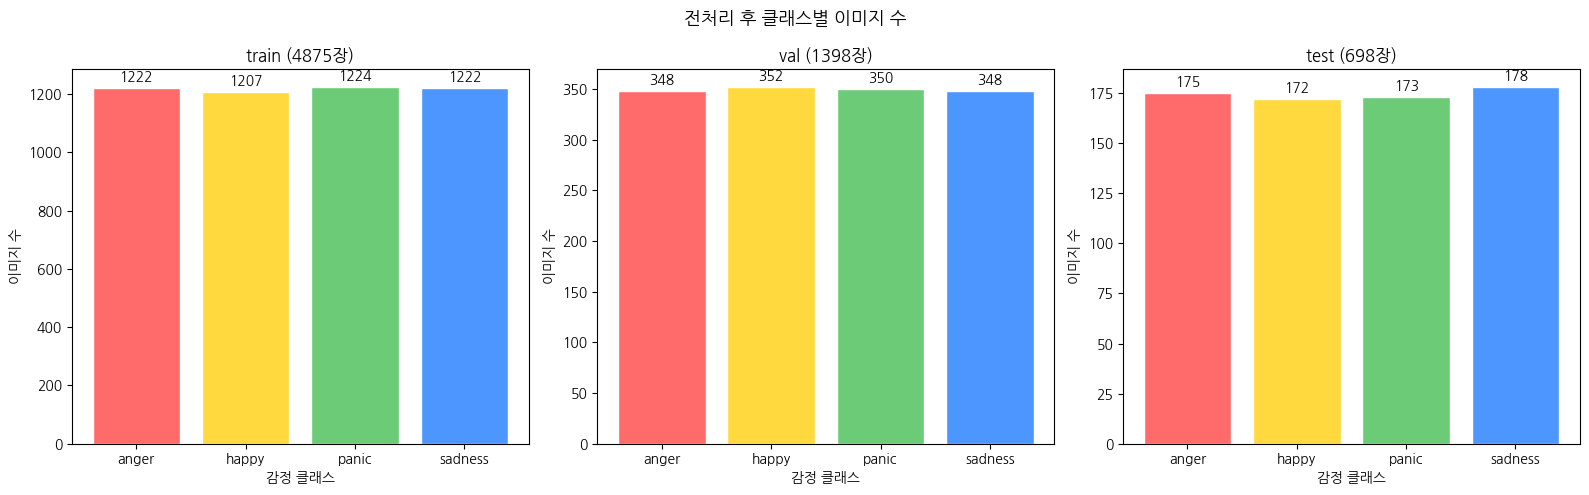

[저장] /workspace/user3/out/plots_v6/result_counts.png
[저장] /workspace/user3/out/stats_v6/result_counts.csv


In [10]:
# Step 10: 전처리 완료 후 클래스별 수량 확인
# 전처리 전후 수량을 비교해 예상치 못한 손실이 없는지 검증
print('=== 전처리 후 클래스별 이미지 수 ===')
result_counts = []
for split in SPLITS:
    for cls in CLASSES:
        cls_dir = OUTPUT_DIR / split / cls
        # cls_dir.exists() 체크: 폴더가 없을 경우 glob 오류 방지
        count   = len([p for p in cls_dir.glob('*')
                       if p.suffix.lower() in IMG_EXT]) if cls_dir.exists() else 0
        result_counts.append({'split': split, 'class': cls, 'count': count})

df_result = pd.DataFrame(result_counts)
# pivot: split을 컬럼으로 변환해서 train/val/test 나란히 비교
print(df_result.pivot(index='class', columns='split', values='count'))
print(f'\n전처리 후 총 이미지: {df_result["count"].sum()}장')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('전처리 후 클래스별 이미지 수', fontsize=13)
colors = ['#FF6B6B', '#FFD93D', '#6BCB77', '#4D96FF']

for ax, split in zip(axes, SPLITS):
    data   = df_result[df_result['split'] == split]
    # reindex: CLASSES 순서대로 정렬
    counts = data.set_index('class')['count'].reindex(CLASSES)
    bars   = ax.bar(counts.index, counts.values, color=colors, edgecolor='white')
    ax.set_title(f'{split} ({counts.sum()}장)')
    ax.set_xlabel('감정 클래스')
    ax.set_ylabel('이미지 수')
    ax.bar_label(bars, padding=3)  # 막대 위에 수치 표시

plt.tight_layout()
plt.savefig(PLOT_DIR / 'result_counts.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'[저장] {PLOT_DIR}/result_counts.png')

# 결과 저장
df_result.to_csv(STAT_DIR / 'result_counts.csv', index=False, encoding='utf-8-sig')
print(f'[저장] {STAT_DIR}/result_counts.csv')

## 10. Class Weight 계산
학습 시 손실 함수에 적용할 가중치를 계산합니다.

=== Class Weight ===
  anger     : 0.9973
  happy     : 1.0097
  panic     : 0.9957
  sadness   : 0.9973

class_weights.json 저장 완료


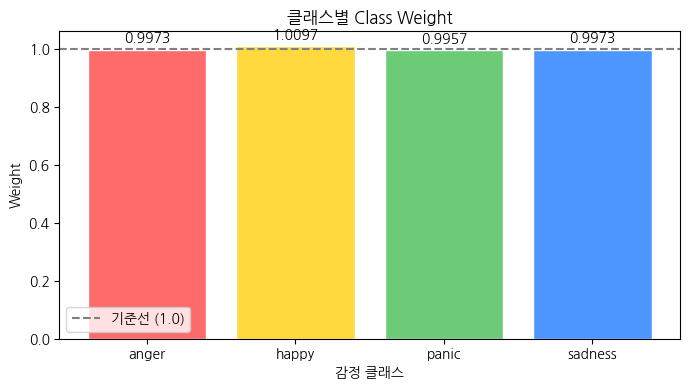

[저장] /workspace/user3/out/plots_v6/class_weights.png


In [11]:
# Step 11: Class Weight 계산
# 클래스 불균형이 있을 때 적은 클래스에 높은 가중치를 줘서 학습을 강화
# balanced: 클래스 수가 적을수록 가중치를 높게 자동 계산

labels = []
for idx, cls in enumerate(CLASSES):
    cls_dir = OUTPUT_DIR / 'train' / cls
    count   = len([p for p in cls_dir.glob('*') if p.suffix.lower() in IMG_EXT])
    # 클래스 인덱스를 이미지 수만큼 반복해서 레이블 배열 구성
    labels.extend([idx] * count)

labels        = np.array(labels)
class_weights = compute_class_weight(
    class_weight='balanced',    # 클래스 비율에 맞게 자동 계산
    classes=np.unique(labels),  # 고유 클래스 인덱스
    y=labels
)

print('=== Class Weight ===')
weight_dict = {}
for cls, w in zip(CLASSES, class_weights):
    weight_dict[cls] = round(w, 4)
    print(f'  {cls:10s}: {w:.4f}')

# JSON 저장: 모델 학습 때 바로 불러쓸 수 있게 OUTPUT_DIR에도 저장
weight_path = OUTPUT_DIR / 'class_weights.json'
with open(weight_path, 'w') as f:
    json.dump(weight_dict, f, indent=2)
# 통계 폴더에도 백업 (mv 후 stats는 남아있으므로)
with open(STAT_DIR / 'class_weights.json', 'w') as f:
    json.dump(weight_dict, f, indent=2)
print('\nclass_weights.json 저장 완료')

plt.figure(figsize=(7, 4))
bars = plt.bar(CLASSES, class_weights,
               color=['#FF6B6B', '#FFD93D', '#6BCB77', '#4D96FF'],
               edgecolor='white')
plt.bar_label(bars, fmt='%.4f', padding=3)
plt.axhline(y=1.0, color='gray', linestyle='--', label='기준선 (1.0)')  # 1.0 기준: 균형 잡힌 클래스
plt.title('클래스별 Class Weight')
plt.xlabel('감정 클래스')
plt.ylabel('Weight')
plt.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / 'class_weights.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'[저장] {PLOT_DIR}/class_weights.png')

## 11. 결과 확인

In [12]:
# Step 12: 최종 저장 현황 출력
# 전처리가 완료된 후 user3에서 확인하고 mv로 shared에 옮기는 방식
print('=== 최종 저장 확인 ===')
total = 0
for split in SPLITS:
    for cls in CLASSES:
        cls_dir = OUTPUT_DIR / split / cls
        count   = len([p for p in cls_dir.glob('*')
                       if p.suffix.lower() in IMG_EXT]) if cls_dir.exists() else 0
        total  += count
        print(f'  {split}/{cls}: {count}장')
print(f'\n총계: {total}장')
print()
print(f'이미지:  {OUTPUT_DIR}')
print(f'시각화:  {PLOT_DIR}')
print(f'통계:    {STAT_DIR}')
print()
print('확인 후 아래 명령어로 shared에 옮기세요')
print(f'  mv {OUTPUT_DIR} /workspace/shared/data/processed/')

=== 최종 저장 확인 ===
  train/anger: 1222장
  train/happy: 1207장
  train/panic: 1224장
  train/sadness: 1222장
  val/anger: 348장
  val/happy: 352장
  val/panic: 350장
  val/sadness: 348장
  test/anger: 175장
  test/happy: 172장
  test/panic: 173장
  test/sadness: 178장

총계: 6971장

이미지:  /workspace/user3/out/data_processed_v6
시각화:  /workspace/user3/out/plots_v6
통계:    /workspace/user3/out/stats_v6

확인 후 아래 명령어로 shared에 옮기세요
  mv /workspace/user3/out/data_processed_v6 /workspace/shared/data/processed/
